### 2. Import necessary libraries

In [2]:
try:
    import datasets, evaluate, accelerate
    import gradio as gr
except ModuleNotFoundError:
    !pip install -U datasets evaluate accelerate gradio
    import datasets, evaluate, accelerate
    import gradio as gr
import random
import numpy as np
import pandas as pd
import torch
import transformers

print(f"Using transformers version: {transformers.__version__}")
print(f"Using torch version: {torch.__version__}")
print(f"Using datasets version: {datasets.__version__}")

Using transformers version: 4.45.2
Using torch version: 2.4.1
Using datasets version: 3.0.1


## 3. Getting a dataset
Building food not food text classification model: need food not food text dataset.

In [3]:
from datasets import load_dataset

# Load the dataset from Hugging Face Hub
dataset = load_dataset(path="mrdbourke/learn_hf_food_not_food_image_captions")

#Inspect the dataset
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 250
    })
})

In [4]:
# What features are there?
dataset.column_names

{'train': ['text', 'label']}

In [5]:
# Access the training split
dataset["train"]

Dataset({
    features: ['text', 'label'],
    num_rows: 250
})

In [6]:
# How about we check out a single sample?
# We can do so with indexing.
dataset["train"][0]

{'text': 'Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
 'label': 'food'}

### Inspect random samples

In [7]:
import random

random_indexs = random.sample(range(len(dataset["train"])), 5)
print(random_indexs)

random_samples = dataset["train"][random_indexs]

print(f"[INFO] Random samples from dataset:\n")
for text,label in zip(random_samples["text"], random_samples["label"]):
    print(f"Text: {text} | Label: {label}")

[146, 155, 30, 39, 54]
[INFO] Random samples from dataset:

Text: Aromatic goat curry, featuring tender goat pieces in a flavorful sauce with spices, served with steamed basmati rice. | Label: food
Text: Set of binoculars placed on a table | Label: not_food
Text: Set of test tubes arranged in a rack | Label: not_food
Text: A bowl of sliced cucumbers with a sprinkle of dill and a side of sour cream | Label: food
Text: A bowl of sliced bell peppers with a sprinkle of paprika and a side of hummus | Label: food


In [8]:
# Get unique label values
dataset["train"].unique("label")

['food', 'not_food']

In [9]:
# Check the count of each label
from collections import Counter
Counter(dataset["train"]["label"])

Counter({'food': 125, 'not_food': 125})

In [10]:
# Turn our dataset into a DataFrame and get a random sample
food_not_food_df = pd.DataFrame(dataset["train"])
food_not_food_df.sample(7)

,text,label
102,A child playing with a golden retriever in the...,not_food
86,"A fruit kabob with a variety of fruits, such a...",food
209,A close-up of a man and his dog sharing a quie...,not_food
59,A white car parked in a driveway with a wooden...,not_food
100,"Pizza with a Mediterranean twist, featuring to...",food
31,"Potatoes, onions, garlic, cauliflower, and bro...",food
170,Colorful area rug brightening up a living room,not_food


In [11]:
food_not_food_df["label"].value_counts()

label
food        125
not_food    125
Name: count, dtype: int64

## 4. Preparing data for text classification

1. Tokenization - turning our text into a numerical representation (machines prefer numbers rather than words), for example, {"a": 0, "b": 1, "c": 2...}.
2. Creating a train/test split - right now our data is in a training split only but we'll create a test set to evaluate our model's performance.

In [12]:
# Create a mapping for labels to numeric value
id2label = {0: "not_food", 1: "food"}
label2id = {"not_food": 0, "food": 1}

print(id2label)
print(label2id)

{0: 'not_food', 1: 'food'}
{'not_food': 0, 'food': 1}


In [13]:
# Create mappings programmatically from dataset
id2label = {idx: label for idx, label in enumerate(dataset["train"].unique("label")[::-1])}
label2id = {label: idx for idx, label in id2label.items()}
print(id2label)
print(label2id)

{0: 'not_food', 1: 'food'}
{'not_food': 0, 'food': 1}


In [14]:
id2label = {}
for idx, label in enumerate(dataset["train"].unique("label")[::-1]):
    print(idx, label)
    id2label[idx] = label

0 not_food
1 food


In [15]:
# Turn labels into 0 or 1
def map_labels_to_number(example):
    example["label"] = label2id[example["label"]]
    return example

example_sample = {"text": "This is a sentence about my favourite food: honey", "label": "food"}

# Test our function
print(map_labels_to_number(example_sample))

{'text': 'This is a sentence about my favourite food: honey', 'label': 1}


In [16]:
# Map our dataset labels to numbers (the whole thing)
# We do this with dataset.map()
dataset = dataset["train"].map(map_labels_to_number)
dataset[:5]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': [1, 0, 0, 0, 0]}

In [17]:
# Shuffle data and look at 5 more random samples
dataset.shuffle()[:5]

{'text': ['Sushi platter featuring a rainbow of colors with salmon, tuna, and avocado.',
  'Microwave oven ready for use on a kitchen counter',
  'A bowl of sliced kiwi with a sprinkle of sugar and a side of yogurt',
  'Silverware organizer keeping cutlery tidy in a kitchen drawer',
  'Camera mounted on a tripod'],
 'label': [1, 0, 1, 0, 0]}

### Split the dataset into training and test sets
* Train set = model will learn patterns on this dataset
* Validation set (optional) = We can tune our model's hyperparameters on this set
* Test set = model will evaluate patterns on this dataset

In [18]:
# Split our dataset into train/test splits
dataset = dataset.train_test_split(test_size=0.2, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})

In [19]:
random_idx_train = random.randint(0, len(dataset["train"]))
random_sample_train = dataset["train"][random_idx_train]
random_sample_train

{'text': 'Mailbox standing by a front door', 'label': 0}

In [20]:
random_idx_test = random.randint(0, len(dataset["test"]))
random_sample_test = dataset["test"][random_idx_test]
random_sample_test

{'text': 'Vibrant red curry with tofu and bell peppers, featuring tofu and sweet bell peppers in a rich coconut milk sauce.',
 'label': 1}

### Tokenizing our text data (Turning text into numbers)
The premise of tokenization is to turn words into numbers.
Eg. "I love pizza!" -> [101, 1045, 2293, 10733, 102]

-

The `transformers` library has in-built support for Hugging Face tokenizers.
And the class `transformers.AutoTokenizer` helps pair a model to a tokenizer.

In [21]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path="distilbert/distilbert-base-uncased",
                                          use_fast=True) # uses fast tokenization (backed by tokenziers library and implemented in Rust) by default, if not available will default to Python implementation

tokenizer

DistilBertTokenizerFast(name_or_path='distilbert/distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [22]:
# Test out the tokenizer
tokenizer("I love pizza")

{'input_ids': [101, 1045, 2293, 10733, 102], 'attention_mask': [1, 1, 1, 1, 1]}

* `input_ids` = our text turned into numbers
* `attention_mask` = Whether or not to pay attention to certain tokens (1 = yes pay attention, 0 = no don't pay attention)

In [23]:
# Get the length of our tokenizer vocab
length_of_tokenizer_vocab = len(tokenizer.vocab)
print(f"[INFO] Number of items in our tokenizer vocab: {length_of_tokenizer_vocab}")

# Get the maximum sequence length the tokenizer can handle
max_tokenizer_input_sequence_length = tokenizer.model_max_length
print(f"[INFO] Max tokenizer input sequence length: {max_tokenizer_input_sequence_length}")

[INFO] Number of items in our tokenizer vocab: 30522
[INFO] Max tokenizer input sequence length: 512


In [24]:
# Does 'daniel' occur in the vocab
tokenizer.vocab["daniel"]

3817

In [25]:
tokenizer("adnan")

{'input_ids': [101, 4748, 7229, 102], 'attention_mask': [1, 1, 1, 1]}

In [26]:
tokenizer.convert_ids_to_tokens(tokenizer("adnan").input_ids)

['[CLS]', 'ad', '##nan', '[SEP]']

In [27]:
# Try to tokenize an emoji
tokenizer.convert_ids_to_tokens(tokenizer("🍕").input_ids)

['[CLS]', '[UNK]', '[SEP]']

In [28]:
# Get the first 5 items in the tokenizer vocab
sorted(tokenizer.vocab.items())[:5]

[('!', 999), ('"', 1000), ('#', 1001), ('##!', 29612), ('##"', 29613)]

In [29]:
random.sample(sorted(tokenizer.vocab.items()), k=5)

[('marina', 9985),
 ('##sund', 25168),
 ('joining', 5241),
 ('analysts', 18288),
 ('coats', 15695)]

### Making a preprocessing function to tokenize text
Want to make it easy to go from sample -> tokenized_sample

In [30]:
def tokenize_text(examples):
    """
    Tokenize given example text and return the tokenized text.
    """
    return tokenizer(examples["text"],
                     padding=True, # pad short sequences to longest sequence in the batch (e.g. if sample length = 100, sample will be padded to 512 or longest sample in batch)
                     truncation=True) # truncate long sequences to the maximum length the model can handle (e.g. if sample length = 1000, model length = 512, sample will be shortened to 512)

In [31]:
example_sample_2 = {"text": "I love pizza", "label": 1}
# Test the function
tokenize_text(example_sample_2)

{'input_ids': [101, 1045, 2293, 10733, 102], 'attention_mask': [1, 1, 1, 1, 1]}

In [32]:
# Check whether truncation is working or not
long_text = "I love pizza " * 1000
len(long_text)

13000

In [33]:
tokenized_long_text = tokenize_text({"text": long_text, "label": 1})
len(tokenized_long_text["input_ids"])

512

In [34]:
# Map our tokenize text function to the dataset
tokenized_dataset = dataset.map(function=tokenize_text,
                                batched=True, # Set batched=True to tokenize across batches of samples at a time rather than one at a time.
                                batch_size=1000
                                )
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 50
    })
})

In [35]:
# Get two samples from the tokenized datasets
train_tokenized_sample = tokenized_dataset["train"][0]
test_tokenized_sample = tokenized_dataset["test"][0]
for key in train_tokenized_sample.keys():
    print(f"[INFO] key: {key}")
    print(f"Train Sample: {train_tokenized_sample[key]}")
    print(f"Test Sample: {test_tokenized_sample[key]}")
    print()

[INFO] key: text
Train Sample: Set of headphones placed on a desk
Test Sample: A slice of pepperoni pizza with a layer of melted cheese

[INFO] key: label
Train Sample: 0
Test Sample: 1

[INFO] key: input_ids
Train Sample: [101, 2275, 1997, 2132, 19093, 2872, 2006, 1037, 4624, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test Sample: [101, 1037, 14704, 1997, 11565, 10698, 10733, 2007, 1037, 6741, 1997, 12501, 8808, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[INFO] key: attention_mask
Train Sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test Sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]



### Setting up an evaluation metric
What we want to do: Use the evaluation metric to get a numerical idea of how our model is performing.

Some common evaluation metrics for classification:

- Accuracy (How many examples out of 100, did you get correct?)
- Precision
- Recall
- F1 Score

Evaluation metric is important because some projects may have an evaluation threshold you need to fulfill. 

In [36]:
import evaluate
import numpy as np
from typing import Tuple

accuracy_metric = evaluate.load("accuracy")

In [37]:
def compute_accuracy(predictions_and_labels: Tuple[np.array, np.array]):
    """
    Computes the accuracy of a model by comparing the predictions and labels. 
    """
    predictions, labels = predictions_and_labels
    if len(predictions.shape) >= 2:
        predictions = np.argmax(predictions, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

In [38]:
# Create example list of predictions and labels
example_predictions_all_correct = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
example_predictions_one_wrong = np.array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])
example_labels = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Test the function
print(f"Accuracy when all predictions are correct: {compute_accuracy((example_predictions_all_correct, example_labels))}")
print(f"Accuracy when one prediction is wrong: {compute_accuracy((example_predictions_one_wrong, example_labels))}")

Accuracy when all predictions are correct: {'accuracy': 1.0}
Accuracy when one prediction is wrong: {'accuracy': 0.9}


### Setting up a model for training

1. ✅ Create and preprocess data.
2. Define the model we'd like use with transformers.AutoModelForSequenceClassification (or another similar model class).
3. Define training arguments (these are hyperparameters for our model) with `transformers.TrainingArguments`.
4. Pass TrainingArguments from 3 and target datasets to an instance of `transformers.Trainer`.
5. Train the model by calling `Trainer.train()`.
6. Save the model (to our local machine or to the Hugging Face Hub).
7. Evaluate the trained model by making and inspecting predctions on the test data.
8. Turn the model into a shareable demo.

In [39]:
from transformers import AutoModelForSequenceClassification

# We are instantiating the base model
model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="distilbert/distilbert-base-uncased", # Base Model
    num_labels=2, # Classify into food/not_food
    id2label=id2label,
    label2id=label2id
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [40]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

#### Our model is comprised of following parts:
1. `embeddings` - embeddings are a form of learned representation of tokens. So if tokensare a direct mapping from token to number, embeddings are a learned vector representation.

2. `transformer` - Our model architecture backbone, this has discovered patterns/relationships in the embeddings.

3. `classifier` - We need to customize this layer to suit our problem.

* Note: If you get input errors from passing a sample to a model, make sure the sample you pass to your model is formatting in the same way your model was trained on. For example, if your model used a specific tokenizer, make sure to tokenize your text before passing it to the model. 

### Count the parameters in our model

* Weights/parameters = small numeric opportunities for a model to learn patterns in data.

* We want to tune weights/parameters in our model that already been pre-learned at a certain datasets to our own problem.

In [41]:
def count_params(model):
    """
    Count the parameters of a PyTorch model. 
    param.requires_grad -> True -> It's going to be updated during training
    if False then it won't be updated during training. 
    """
    trainable_parameters = sum(param.numel() for param in model.parameters() if param.requires_grad)
    total_parameters = sum(param.numel() for param in model.parameters())
    return {"trainable_parameters": trainable_parameters, "total_parameters": total_parameters}

In [42]:
count_params(model)

{'trainable_parameters': 66955010, 'total_parameters': 66955010}

### Create a directory for saving models

In [43]:
# Create model output directory
from pathlib import Path

# Create models dir
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Create model save name
model_save_name = "learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

# Create model save path
model_save_dir = Path(models_dir, model_save_name)

model_save_dir

PosixPath('models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased')

### Setting up training arguments (Hyperparameters) with TrainingArguments

* Define training arguments for training our model `transformers.TrainingArguments`

    * Hyperparameters = Settings on your model that you can adjust
    * Parameters = Weights/Patters in the model that get updated automatically. 

In [44]:
from transformers import TrainingArguments
from dotenv import load_dotenv
import os

load_dotenv()

print(f"[INFO] Saving model checkpoints to: {model_save_dir}")

# Create training arguments
training_args = TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=0.0001,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10, # Laps over the data that our model is going to do
    eval_strategy="epoch", # was previously "evaluation_strategy"
    save_strategy="epoch",
    save_total_limit=3, # limit the total amount of save checkpoints (so we don't save num_epochs checkpoints)
    use_cpu=False, # set to False by default, will use CUDA GPU or MPS device if available
    seed=42, # set to 42 by default for reproducibility
    load_best_model_at_end=True, # load the best model when finished training
    logging_strategy="epoch", # log training results every epoch
    report_to="none", # optional: log experiments to Weights & Biases/other similar experimenting tracking services (we'll turn this off for now) 
    # push_to_hub=True # optional: automatically upload the model to the Hub (we'll do this manually later on)
    hub_token=os.getenv("HF_TOKEN"), # optional: add your Hugging Face Hub token to push to the Hub (will default to huggingface-cli login)
    hub_private_repo=False # optional: make the uploaded model private (defaults to False)
)

[INFO] Saving model checkpoints to: models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased


In [45]:
# Optional: Print out training_args to inspect (warning, it is quite a long output)
training_args

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=False,
evaluation_s

### Setting up an instance of Trainer - 4 

1. ✅ Create and preprocess data.
2. ✅ Define the model we'd like use with transformers.AutoModelForSequenceClassification (or another similar model class).
3. ✅ Define training arguments (these are hyperparameters for our model) with `transformers.TrainingArguments`.
4. Pass TrainingArguments from 3 and target datasets to an instance of `transformers.Trainer`.
5. Train the model by calling `Trainer.train()`.
6. Save the model (to our local machine or to the Hugging Face Hub).
7. Evaluate the trained model by making and inspecting predctions on the test data.
8. Turn the model into a shareable demo.

In [46]:
from transformers import Trainer

#Setup Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_accuracy
)
trainer

### Train the model by calling `Trainer.train()` - 5

1. ✅ Create and preprocess data.
2. ✅ Define the model we'd like use with transformers.AutoModelForSequenceClassification (or another similar model class).
3. ✅ Define training arguments (these are hyperparameters for our model) with `transformers.TrainingArguments`.
4. ✅ Pass TrainingArguments from 3 and target datasets to an instance of `transformers.Trainer`.
5. Train the model by calling `Trainer.train()`.
6. Save the model (to our local machine or to the Hugging Face Hub).
7. Evaluate the trained model by making and inspecting predctions on the test data.
8. Turn the model into a shareable demo.

In [47]:
result = trainer.train()

 10%|█         | 7/70 [00:02<00:15,  3.96it/s]

{'loss': 0.3597, 'grad_norm': 1.1361223459243774, 'learning_rate': 9e-05, 'epoch': 1.0}


                                              
 10%|█         | 7/70 [00:02<00:15,  3.96it/s]

{'eval_loss': 0.04467589408159256, 'eval_accuracy': 1.0, 'eval_runtime': 0.192, 'eval_samples_per_second': 260.43, 'eval_steps_per_second': 10.417, 'epoch': 1.0}


 20%|██        | 14/70 [00:04<00:12,  4.35it/s]

...

{'loss': 0.0006, 'grad_norm': 0.009600084275007248, 'learning_rate': 0.0, 'epoch': 10.0}


                                               
100%|██████████| 70/70 [00:25<00:00,  4.77it/s]

{'eval_loss': 0.0005216638674028218, 'eval_accuracy': 1.0, 'eval_runtime': 0.0929, 'eval_samples_per_second': 538.301, 'eval_steps_per_second': 21.532, 'epoch': 10.0}


100%|██████████| 70/70 [00:26<00:00,  2.63it/s]

{'train_runtime': 26.6113, 'train_samples_per_second': 75.156, 'train_steps_per_second': 2.63, 'train_loss': 0.03940916032131229, 'epoch': 10.0}


In [48]:
result.metrics

{'train_runtime': 26.6113,
 'train_samples_per_second': 75.156,
 'train_steps_per_second': 2.63,
 'total_flos': 18110777160000.0,
 'train_loss': 0.03940916032131229,
 'epoch': 10.0}

In [49]:
# Inspect training metrics
for key, value in result.metrics.items():
    print(f"{key} : {value}")

train_runtime : 26.6113
train_samples_per_second : 75.156
train_steps_per_second : 2.63
total_flos : 18110777160000.0
train_loss : 0.03940916032131229
epoch : 10.0


### Save the model for later use

In [50]:
# Save Model
print(f"[INFO] Saving model to {model_save_dir}")
trainer.save_model(output_dir=model_save_dir)

[INFO] Saving model to models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased


### Inspect the model training metrics

In [51]:
# Get training history
trainer_history_all = trainer.state.log_history
trainer_history_metrics = trainer_history_all[:-1] # Everything except the last one
trainer_history_training_time = trainer_history_all[-1]

trainer_history_training_time

#View the first 3
trainer_history_metrics[:3]

[{'loss': 0.3597,
  'grad_norm': 1.1361223459243774,
  'learning_rate': 9e-05,
  'epoch': 1.0,
  'step': 7},
 {'eval_loss': 0.04467589408159256,
  'eval_accuracy': 1.0,
  'eval_runtime': 0.192,
  'eval_samples_per_second': 260.43,
  'eval_steps_per_second': 10.417,
  'epoch': 1.0,
  'step': 7},
 {'loss': 0.0233,
  'grad_norm': 0.13583998382091522,
  'learning_rate': 8e-05,
  'epoch': 2.0,
  'step': 14}]

In [52]:
import pprint

# Extract eval and training metrics
trainer_history_training_set = []
trainer_history_eval_set = []

# Loop through our metrics
for item in trainer_history_metrics:
    item_keys = list(item.keys())
    if any("eval" in item for item in item_keys):
        trainer_history_eval_set.append(item)
    else:
        trainer_history_training_set.append(item)

# Show the first item from each
print(f"First item in training set:")
pprint.pprint(trainer_history_training_set[:2])

print(f"\nFirst two item in eval epochs:")
pprint.pprint(trainer_history_eval_set[:2])

First item in training set:
[{'epoch': 1.0,
  'grad_norm': 1.1361223459243774,
  'learning_rate': 9e-05,
  'loss': 0.3597,
  'step': 7},
 {'epoch': 2.0,
  'grad_norm': 0.13583998382091522,
  'learning_rate': 8e-05,
  'loss': 0.0233,
  'step': 14}]

First two item in eval epochs:
[{'epoch': 1.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.04467589408159256,
  'eval_runtime': 0.192,
  'eval_samples_per_second': 260.43,
  'eval_steps_per_second': 10.417,
  'step': 7},
 {'epoch': 2.0,
  'eval_accuracy': 0.98,
  'eval_loss': 0.03355254977941513,
  'eval_runtime': 0.0837,
  'eval_samples_per_second': 597.656,
  'eval_steps_per_second': 23.906,
  'step': 14}]


### Taking a look at the loss curves

Loss curves = A good visualization of your model's performance over time.

Ideally, loss curves will trend downwards.

In [53]:
# Create a pandas DataFrame for the training and evaluation metrics
trainer_history_train_df = pd.DataFrame(trainer_history_training_set)
trainer_history_eval_df = pd.DataFrame(trainer_history_eval_set)

trainer_history_train_df.head()

,loss,grad_norm,learning_rate,epoch,step
0,0.3597,1.136122,0.00009,1.0,7
1,0.0233,0.135840,0.00008,2.0,14
2,0.0043,0.043655,0.00007,3.0,21
3,0.0020,0.024585,0.00006,4.0,28
4,0.0012,0.023144,0.00005,5.0,35


In [54]:
trainer_history_eval_df.head()

,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.044676,1.00,0.1920,260.430,10.417,1.0,7
1,0.033553,0.98,0.0837,597.656,23.906,2.0,14
2,0.004203,1.00,0.0831,601.917,24.077,3.0,21
3,0.001147,1.00,0.0829,603.091,24.124,4.0,28
4,0.000821,1.00,0.0824,607.098,24.284,5.0,35


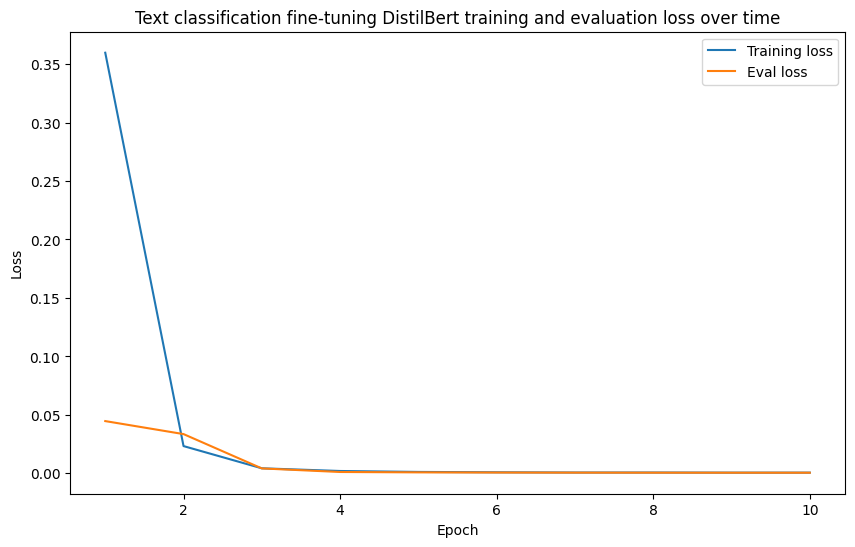

In [55]:
# Plot the loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(trainer_history_train_df["epoch"], trainer_history_train_df["loss"], label="Training loss")
plt.plot(trainer_history_eval_df["epoch"], trainer_history_eval_df["eval_loss"], label="Eval loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Text classification fine-tuning DistilBert training and evaluation loss over time")
plt.legend()
plt.show()

### Pushing our model to the Hugging Face Hub - 6

1. ✅ Create and preprocess data.
2. ✅ Define the model we'd like use with transformers.AutoModelForSequenceClassification (or another similar model class).
3. ✅ Define training arguments (these are hyperparameters for our model) with `transformers.TrainingArguments`.
4. ✅ Pass TrainingArguments from 3 and target datasets to an instance of `transformers.Trainer`.
5. ✅ Train the model by calling `Trainer.train()`.
6. Save the model (to our local machine or to the Hugging Face Hub).
7. Evaluate the trained model by making and inspecting predctions on the test data.
8. Turn the model into a shareable demo.

In [56]:
# Save our model to the Hugging Face Hub
model_upload_url = trainer.push_to_hub(
    commit_message="Uploading food not food text classifier model",
    token=os.getenv("HF_TOKEN")
)
print(f"[INFO] Model successfully uploaded to the Hugging Face Hub with URL: {model_upload_url}")

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]


training_args.bin: 100%|██████████| 5.30k/5.30k [00:00<00:00, 14.9kB/s]






































































































































































































































































































































































































































































































































































































































































































































































































































































































[INFO] Model successfully uploaded to the Hugging Face Hub with URL: https://huggingface.co/mdarefin/learn_hf_food_not_food_text_classifier-distilbert-base-uncased/tree/main/


### Making and evaluating predictions on the test data

1. ✅ Create and preprocess data.
2. ✅ Define the model we'd like use with transformers.AutoModelForSequenceClassification (or another similar model class).
3. ✅ Define training arguments (these are hyperparameters for our model) with `transformers.TrainingArguments`.
4. ✅ Pass TrainingArguments from 3 and target datasets to an instance of `transformers.Trainer`.
5. ✅ Train the model by calling `Trainer.train()`.
6. ✅ Save the model (to our local machine or to the Hugging Face Hub).
7. Evaluate the trained model by making and inspecting predctions on the test data.
8. Turn the model into a shareable demo.

In [57]:
# Perform predictions on the test data
predictions_all = trainer.predict(tokenized_dataset["test"])
prediction_values = predictions_all.predictions
prediction_metrics = predictions_all.metrics

print(f"[INFO] Prediction metrics on the test data:")
prediction_metrics

100%|██████████| 2/2 [00:00<00:00, 55.78it/s]

[INFO] Prediction metrics on the test data:


{'test_loss': 0.0005216638674028218,
 'test_accuracy': 1.0,
 'test_runtime': 0.1397,
 'test_samples_per_second': 357.938,
 'test_steps_per_second': 14.318}

### Let's get predicted probabilities and evalute by hand

In [58]:
# Predict logits (raw output of the model) -> Prediction probabilities with torch.softmax -> Predicted labels

import torch
from sklearn.metrics import accuracy_score

# 1. Get prediction probabilities with torch.softmax
pred_probs = torch.softmax(torch.tensor(prediction_values), dim=1)

# 2. Get the predicted labels
pred_labels = torch.argmax(pred_probs, dim=1)

# 3. Get the true labels
true_labels = tokenized_dataset["test"]["label"]

# 4. Compute prediction labels to true labels and get the test accuracy
test_accuracy = accuracy_score(y_true=true_labels, y_pred=pred_labels)
print(f"[INFO] Test Accuracy: {test_accuracy * 100}")

[INFO] Test Accuracy: 100.0


### Exploring our models prediction probabilities

It's a very good way to evaluate a model by sorting predictions by prediction probabilities and seeing where the model went wrong.

In [59]:
# Make a DataFrame of test predictions
test_predictions_df = pd.DataFrame({
    "text": tokenized_dataset["test"]["text"],
    "true_labels": true_labels,
    "pred_labels": pred_labels,
    "pred_prob": torch.max(pred_probs, dim=1).values
})
test_predictions_df.head()

,text,true_labels,pred_labels,pred_prob
0,A slice of pepperoni pizza with a layer of mel...,1,1,0.999458
1,Red brick fireplace with a mantel serving as a...,0,0,0.999521
2,A bowl of sliced bell peppers with a sprinkle ...,1,1,0.999459
3,Set of mugs hanging on a hook,0,0,0.999544
4,Standing floor lamp providing light next to an...,0,0,0.999523


In [60]:
# Show 10 examples with low prediction probability
test_predictions_df.sort_values("pred_prob", ascending=True).head(10)

,text,true_labels,pred_labels,pred_prob
40,A bowl of cherries with a sprig of mint for ga...,1,1,0.999431
34,"Mouthwatering mushroom curry, featuring shiita...",1,1,0.999451
43,Set of muffin tins stacked together,0,0,0.999451
13,"Comforting lamb curry bowl, featuring tender l...",1,1,0.999453
32,"Comforting lentil dal curry, featuring nutty l...",1,1,0.999454
42,"Boxes of apples, pears, pineapple, manadrins a...",1,1,0.999454
46,A bowl of sliced kiwi with a sprinkle of sugar...,1,1,0.999454
14,Two handfuls of bananas in a fruit bowl with g...,1,1,0.999454
35,Luxurious coconut shrimp curry on a generous p...,1,1,0.999455
8,"Tangy tomato curry with chicken, featuring ten...",1,1,0.999455


### Making and inspecting predictions on custom text data

In [61]:
local_model_path = "models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

huggingface_model_path = "mdarefin/learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

### Discussing ways to make predictions (inference)

* Note: Whenever we hear the word "inference" it means to use a model to make predictions on data.

Two main ways to perform inference: 

1. **Pipeline mode** - Using `transformers.pipeline` to load our model and perform text classification.

2. **PyTorch mode** - Using a combination of `transformers.AutoTokenizer` and `transformers.AutoModelForSequenceClassification` and passing each our target model name.

Each mode supports:

1. Predictions one at a time (Fast but can be slower with many many samples).
    * Helpful for say a comment system and comments happen sporadically, to predict either the comment was "spam" or "not spam".

2. Batches of predictions at a time (Faster but up to a point, e.g. say you predict on 32 samples at a time, this may be way faster than one at a time. But if you go 128 at a time, you may not see many more speedups.)
    * Helpful for when you have a large static database or many samples coming in at once. 

In [62]:
# Setup our device for making predictions
# Note: Generally the faster the hardware accelerator, the faster the predictions.
# For example if you have a dedicated GPU, you should use it over CPU.

def set_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    return device

DEVICE = set_device()
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: mps


### Making predictions with pipeline mode

In [63]:
import torch
from transformers import pipeline

# Set the batch size (Experimental Hyper-Parameter)
BATCH_SIZE = 32 # reminder: Prediction speed often increases with higher batch size (e.g. 1 -> 32 but can saturate at even higher bath sizes)

# Create an instance of transformers.pipeline 
food_not_food_classifier = pipeline(
    task="text-classification",
    model=local_model_path,
    device=DEVICE,
    top_k=1,
    batch_size=BATCH_SIZE)

In [64]:
test_custom_sentence = "Text that we could make up like this!"
food_not_food_classifier(test_custom_sentence)

[[{'label': 'not_food', 'score': 0.9992192983627319}]]

In [65]:
test_custom_sentence = "For breakfast I had rice cakes and fish!"
food_not_food_classifier(test_custom_sentence)

[[{'label': 'food', 'score': 0.9994112253189087}]]

In [66]:
test_custom_sentence = "My local coffee shop has the best croissants"
food_not_food_classifier(test_custom_sentence)

[[{'label': 'not_food', 'score': 0.9990148544311523}]]

In [67]:
del food_not_food_classifier

In [68]:
# Use pipeline with a model from Hugging Face
food_not_food_classifier = pipeline(
    task="text-classification",
    model=huggingface_model_path,
    device=DEVICE,
    top_k=1,
    batch_size=BATCH_SIZE)

In [69]:
test_not_food_sentence = "The Gate by Pete2453"

In [70]:
food_not_food_classifier(test_not_food_sentence)

[[{'label': 'not_food', 'score': 0.9991338849067688}]]

### Making multiple predictions at the same time with batch prediction

In [71]:
# Create a list of sentences to make predictions on
sentences = [
    "I whipped up a fresh batch of code, but it seems to have a syntax error.",
    "We need to marinate these ideas overnight before presenting them to the client.",
    "The new software is definitely a spicy upgrade, taking some time to get used to.",
    "Her social media post was the perfect recipe for a viral sensation.",
    "He served up a rebuttal full of facts, leaving his opponent speechless.",
    "The team needs to simmer down a bit before tackling the next challenge.",
    "The presentation was a delicious blend of humor and information, keeping the audience engaged.",
    "A beautiful array of fake wax foods (shokuhin sampuru) in the front of a Japanese restaurant.",
    "Daniel Bourke is really cool :D",
    "My favoruite food is biltong!"
]

food_not_food_classifier(sentences)

[[{'label': 'not_food', 'score': 0.9892727136611938}],
 [{'label': 'not_food', 'score': 0.9987151622772217}],
 [{'label': 'not_food', 'score': 0.9883084297180176}],
 [{'label': 'not_food', 'score': 0.9975230097770691}],
 [{'label': 'not_food', 'score': 0.9985820055007935}],
 [{'label': 'not_food', 'score': 0.99747234582901}],
 [{'label': 'not_food', 'score': 0.9936704635620117}],
 [{'label': 'food', 'score': 0.9994200468063354}],
 [{'label': 'not_food', 'score': 0.9989461302757263}],
 [{'label': 'not_food', 'score': 0.9606119394302368}]]

In [72]:
sentences = [
    "I baked a fresh loaf of sourdough bread, and the house smells amazing.",
    "The chocolate cake I made was rich and decadent, a real treat for the senses.",
    "We had a hearty breakfast of scrambled eggs, crispy bacon, and toast.",
    "The sushi was beautifully arranged, each piece a delicate bite of flavor.",
    "Grilled steak with a side of roasted vegetables made for a satisfying dinner.",
    "A cup of hot, aromatic coffee was exactly what I needed this morning.",
    "The pasta dish was a creamy blend of Parmesan and garlic, topped with fresh basil.",
    "I love the crunch of a fresh apple, it's the perfect afternoon snack.",
    "Homemade pizza with a crispy crust and fresh toppings is a weekend favorite.",
    "A bowl of ramen with pork belly and a soft-boiled egg was pure comfort food.",
    "The new software update is really a breath of fresh air, improving performance.",
    "His speech was a fiery take on the current state of politics, igniting debates.",
    "We need to digest the feedback before making any major changes to the project.",
    "Her artwork was a visual feast, blending colors and textures in a unique way.",
    "The team needs to chew over these new ideas before moving forward with the plan.",
    "He served up a fantastic solution to the problem, surprising everyone in the room.",
    "The project’s timeline is heating up, and we need to pick up the pace.",
    "The conversation flowed smoothly, with everyone contributing to the dialogue.",
    "Her emotions simmered beneath the surface, waiting for the right moment to spill over.",
    "The code was a tangled mess, requiring patience and skill to untangle it."
]
food_not_food_classifier(sentences)

[[{'label': 'food', 'score': 0.9994605183601379}],
 [{'label': 'food', 'score': 0.9994339346885681}],
 [{'label': 'food', 'score': 0.9994558691978455}],
 [{'label': 'food', 'score': 0.9994434714317322}],
 [{'label': 'food', 'score': 0.9994567036628723}],
 [{'label': 'food', 'score': 0.8324252367019653}],
 [{'label': 'food', 'score': 0.9994577765464783}],
 [{'label': 'food', 'score': 0.9994421601295471}],
 [{'label': 'food', 'score': 0.9994643330574036}],
 [{'label': 'food', 'score': 0.9994564652442932}],
 [{'label': 'not_food', 'score': 0.99847012758255}],
 [{'label': 'not_food', 'score': 0.9989646673202515}],
 [{'label': 'not_food', 'score': 0.9970491528511047}],
 [{'label': 'not_food', 'score': 0.9987508058547974}],
 [{'label': 'not_food', 'score': 0.9988517761230469}],
 [{'label': 'not_food', 'score': 0.9988735318183899}],
 [{'label': 'not_food', 'score': 0.998446524143219}],
 [{'label': 'not_food', 'score': 0.999283492565155}],
 [{'label': 'not_food', 'score': 0.9993656277656555}],

In [73]:
confusing_sentences = [
    "She served up a plate of fresh ideas, garnished with a sprinkle of humor.",
    "The project needs to marinate a bit before we can really dig in.",
    "His words were seasoned with just the right amount of sarcasm.",
    "We should let that concept bake in the oven of our minds for a while.",
    "They were chopping through data, trying to get to the core of the problem.",
    "Her response was as smooth as whipped cream, covering up the tension in the room.",
    "We’re in the final stretch, just need to simmer on this a little longer.",
    "The presentation was a bit undercooked, it needs more preparation.",
    "He’s been chewing on that issue for days, but hasn’t found a solution.",
    "That plan is half-baked; we need more time to fully develop it."
]
food_not_food_classifier(confusing_sentences)

[[{'label': 'food', 'score': 0.9992883801460266}],
 [{'label': 'not_food', 'score': 0.9987466335296631}],
 [{'label': 'not_food', 'score': 0.9817487597465515}],
 [{'label': 'not_food', 'score': 0.99909508228302}],
 [{'label': 'not_food', 'score': 0.9991939663887024}],
 [{'label': 'food', 'score': 0.9992302656173706}],
 [{'label': 'not_food', 'score': 0.9966374635696411}],
 [{'label': 'not_food', 'score': 0.9769548177719116}],
 [{'label': 'not_food', 'score': 0.9951006770133972}],
 [{'label': 'not_food', 'score': 0.9966024160385132}]]

In [74]:
confusing_sentences = [
    "She served up a plate of fresh ideas, garnished with a sprinkle of humor.",
    "The project needs to marinate a bit before we can really dig in.",
    "His words were seasoned with just the right amount of sarcasm.",
    "We should let that concept bake in the oven of our minds for a while.",
    "They were chopping through data, trying to get to the core of the problem.",
    "Her response was as smooth as whipped cream, covering up the tension in the room.",
    "We’re in the final stretch, just need to simmer on this a little longer.",
    "The presentation was a bit undercooked, it needs more preparation.",
    "He’s been chewing on that issue for days, but hasn’t found a solution.",
    "That plan is half-baked; we need more time to fully develop it.",
    "A symphony of textures and flavors.",
    "Indulge in the sweet aroma of possibility.",
    "Savoring the moment, one bite at a time.",
    "A feast for the senses.",
    "A melting pot of cultures.",
    "A taste of adventure.",
    "The perfect pairing.",
    "A culinary masterpiece.",
    "A feast for the eyes.",
    "A flavor explosion."
]
food_not_food_classifier(confusing_sentences)

[[{'label': 'food', 'score': 0.9992883801460266}],
 [{'label': 'not_food', 'score': 0.9987466335296631}],
 [{'label': 'not_food', 'score': 0.9817487597465515}],
 [{'label': 'not_food', 'score': 0.99909508228302}],
 [{'label': 'not_food', 'score': 0.9991939663887024}],
 [{'label': 'food', 'score': 0.9992302656173706}],
 [{'label': 'not_food', 'score': 0.9966374635696411}],
 [{'label': 'not_food', 'score': 0.9769548177719116}],
 [{'label': 'not_food', 'score': 0.9951006770133972}],
 [{'label': 'not_food', 'score': 0.9966024160385132}],
 [{'label': 'food', 'score': 0.8879058957099915}],
 [{'label': 'food', 'score': 0.9990308284759521}],
 [{'label': 'not_food', 'score': 0.9927587509155273}],
 [{'label': 'not_food', 'score': 0.9987695813179016}],
 [{'label': 'not_food', 'score': 0.9953023195266724}],
 [{'label': 'not_food', 'score': 0.9983828067779541}],
 [{'label': 'not_food', 'score': 0.9974533915519714}],
 [{'label': 'not_food', 'score': 0.9986893534660339}],
 [{'label': 'not_food', 'sco

### Time our model across larger sample sizes

In [75]:
import time

# Create 1000 sentences
sentences_1000 = sentences * 50

len(sentences_1000)

# Time how long it takes to make predictions on all sentences (one at a time)
print(f"[INFO] Number of sentences: {len(sentences_1000)}")

start_time_one_at_a_time = time.time()

for sentence in sentences_1000:
    # Make a prediction
    food_not_food_classifier(sentence)

end_time_one_at_a_time = time.time()

total_time_one_at_a_time = end_time_one_at_a_time - start_time_one_at_a_time
avg_time_per_pred = total_time_one_at_a_time / len(sentences_1000)

print(f"[INFO] Total time for making predictions on {len(sentences_1000)} samples one at a time: {total_time_one_at_a_time}s")
print(f"[INFO] Avg time per prediction one at a time: {avg_time_per_pred}s")

[INFO] Number of sentences: 1000
[INFO] Total time for making predictions on 1000 samples one at a time: 12.056989908218384s
[INFO] Avg time per prediction one at a time: 0.012056989908218383s


In [76]:
# Let's now use pipeline in batches

for i in [5, 50, 500, 5000]:
    sentence_big = sentences * i
    print(f"[INFO] Number of sentences: {len(sentence_big)}")

    start_time = time.time()
    # Predict on all sentences in batch mode
    food_not_food_classifier(sentence_big)
    end_time = time.time()

    total_time_per_all_sentences_batch_mode = end_time - start_time
    avg_time_per_sentence_batch_mode = total_time_per_all_sentences_batch_mode / len(sentence_big)

    print(f"[INFO] Inference time for {len(sentence_big)} sentences batch mode: {round(total_time_per_all_sentences_batch_mode, 6)}")

    print(f"[INFO] Avg inference time per sentence: {round(avg_time_per_sentence_batch_mode, 8)}")
    print()

[INFO] Number of sentences: 100
[INFO] Inference time for 100 sentences batch mode: 0.266469
[INFO] Avg inference time per sentence: 0.00266469

[INFO] Number of sentences: 1000
[INFO] Inference time for 1000 sentences batch mode: 1.169805
[INFO] Avg inference time per sentence: 0.00116981

[INFO] Number of sentences: 10000
[INFO] Inference time for 10000 sentences batch mode: 11.097816
[INFO] Avg inference time per sentence: 0.00110978

[INFO] Number of sentences: 100000
[INFO] Inference time for 100000 sentences batch mode: 110.227831
[INFO] Avg inference time per sentence: 0.00110228



### Making Predictions with PyTorch

Steps with PyTorch predictions:

1. Create the tokenizer with `AutoTokenizer`.
2. Create the model with `AutoModel` (AutoModelForSequenceClassification).
3. Tokenize text with 1
4. Make prediction with 2
5. Format prediction

In [77]:
from transformers import AutoTokenizer

# Setup the model path
model_path = "mdarefin/learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

# Create an example to predict on
sample_food_text = "A delicious photo of a plate of scramble eggs, toast and bacon"

# Prepare the tokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_path)
inputs = tokenizer(sample_food_text, return_tensors="pt") # "pt" stands for PyTorch
inputs


{'input_ids': tensor([[  101,  1037, 12090,  6302,  1997,  1037,  5127,  1997, 25740,  6763,
          1010, 15174,  1998, 11611,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [79]:
from transformers import AutoModelForSequenceClassification

# Load our text classification model
model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path=model_path)
# model

In [80]:
import torch

model.eval()
# with torch.no_grad():
with torch.inference_mode():
    output = model(**inputs) # "**" means input all of the dictionary keys as named arguments/parameters
    outputs_verbose = model(input_ids=inputs["input_ids"],
                             attention_mask=inputs["attention_mask"])
    

In [81]:
output

SequenceClassifierOutput(loss=None, logits=tensor([[-3.7321,  3.7761]]), hidden_states=None, attentions=None)

In [82]:
outputs_verbose

SequenceClassifierOutput(loss=None, logits=tensor([[-3.7321,  3.7761]]), hidden_states=None, attentions=None)

In [83]:
# Convert logits to prediction probability + label
predicted_class_id = output.logits.argmax().item()
prediction_probability = torch.softmax(output.logits, dim=1).max().item()

print(f"Text: {sample_food_text}")
print(f"Predicted label: {model.config.id2label[predicted_class_id]}")
print(f"Prediction probability: {prediction_probability}")

Text: A delicious photo of a plate of scramble eggs, toast and bacon
Predicted label: food
Prediction probability: 0.9994516968727112


In [84]:
food_not_food_classifier(sample_food_text)

[[{'label': 'food', 'score': 0.9994516968727112}]]

### Putting it all together

Let's go end-to-end.

From data import to model building to model evaluation to model saving for our text classification project.

In [85]:
# 1. Import necessary packages
import pprint
from pathlib import Path

import numpy as np
import torch

import datasets
import evaluate

from transformers import pipeline
from transformers import TrainingArguments, Trainer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 2. Setup variables for model training and saving pipeline
DATASET_NAME = "mrdbourke/learn_hf_food_not_food_image_captions"
MODEL_NAME = "distilbert/distilbert-base-uncased"
MODEL_SAVE_DIR_NAME = "models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

# 3. Create a directory for saving models
# Note: This will override our existing saved model (if there is one)
print(f"[INFO] Creating directory for saving models: {MODEL_SAVE_DIR_NAME}")
model_save_dir = Path(MODEL_SAVE_DIR_NAME)
model_save_dir.mkdir(parents=True, exist_ok=True)

# 4. Load and preprocess the dataset from Hugging Face Hub
print(f"[INFO] Downloading dataset from Hugging Face Hub, name: {DATASET_NAME}")
dataset = datasets.load_dataset(path=DATASET_NAME)

# Create mappings from id2label and label2id (adjust these for your target dataset, can also create these programmatically)
id2label = {0: "not_food", 1: "food"}
label2id = {"not_food": 0, "food": 1}

# Create function to map IDs to labels in dataset
def map_labels_to_number(example):
    example["label"] = label2id[example["label"]]
    return example

# Map preprocessing function to dataset
dataset = dataset["train"].map(map_labels_to_number)

# Split the dataset into train/test sets
dataset = dataset.train_test_split(test_size=0.2, seed=42)

# 5. Import a tokenizer and map it to our dataset
print(f"[INFO] Tokenizing text for model training with tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=MODEL_NAME,
                                          use_fast=True)

# Create a preprocessing function to tokenize text
def tokenize_text(examples):
    return tokenizer(examples["text"],
                     padding=True,
                     truncation=True)

tokenized_dataset = dataset.map(function=tokenize_text,
                                batched=True,
                                batch_size=1000)

# 6. Set up an evaluation metric & function to evaluate our model
accuracy_metric = evaluate.load("accuracy")

def compute_accuracy(predictions_and_labels):
    predictions, labels = predictions_and_labels

    if len(predictions.shape) >= 2:
        predictions = np.argmax(predictions, axis=1)
    
    return accuracy_metric.compute(predictions=predictions, references=labels) # note: use "references" parameter rather than "labels"


# 7. Import a model and prepare it for training 
print(f"[INFO] Loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
print(f"[INFO] Model loading complete!")

# Setup TrainingArguments
training_args = TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=0.0001,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    use_cpu=False,
    seed=42,
    load_best_model_at_end=True,
    logging_strategy="epoch",
    report_to="none",
    push_to_hub=False,
    hub_private_repo=False # Note: if set to False, your model will be publically available
)

# Create Trainer instance and train model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_accuracy
)

# 8. Train the model on our text dataset
print(f"[INFO] Commencing model training...")
results = trainer.train()

# 9. Save the trained model (note: this will overwrite our previous model, this is ok)
print(f"[INFO] Model training complete, saving model to local path: {model_save_dir}")
trainer.save_model(output_dir=model_save_dir)

# 10. Push the model to the Hugging Face Hub
print(f"[INFO] Uploading model to Hugging Face Hub...")
model_upload_url = trainer.push_to_hub(
    commit_message="Uploading food not food text classifier model",
    # token="YOUR_HF_TOKEN_HERE" # requires a "write" HF token 
)
print(f"[INFO] Model upload complete, model available at: {model_upload_url}")

# 11. Evaluate the model on the test data
print(f"[INFO] Performing evaluation on test dataset...")
predictions_all = trainer.predict(tokenized_dataset["test"])
prediction_values = predictions_all.predictions
prediction_metrics = predictions_all.metrics

print(f"[INFO] Prediction metrics on the test data:")
pprint.pprint(prediction_metrics)

[INFO] Creating directory for saving models: models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased
[INFO] Downloading dataset from Hugging Face Hub, name: mrdbourke/learn_hf_food_not_food_image_captions
[INFO] Tokenizing text for model training with tokenizer: distilbert/distilbert-base-uncased


Map: 100%|██████████| 50/50 [00:00<00:00, 6716.90 examples/s]


[INFO] Loading model: distilbert/distilbert-base-uncased


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Model loading complete!
[INFO] Commencing model training...


...

{'train_runtime': 30.25, 'train_samples_per_second': 66.116, 'train_steps_per_second': 2.314, 'train_loss': 0.045028373968255306, 'epoch': 10.0}
[INFO] Model training complete, saving model to local path: models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased
[INFO] Uploading model to Hugging Face Hub...


Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]
training_args.bin: 100%|██████████| 5.30k/5.30k [00:00<00:00, 16.1kB/s]
model.safetensors: 100%|██████████| 268M/268M [02:04<00:00, 2.16MB/s]
Upload 2 LFS files: 100%|██████████| 2/2 [02:04<00:00, 62.24s/it] 


[INFO] Model upload complete, model available at: https://huggingface.co/mdarefin/learn_hf_food_not_food_text_classifier-distilbert-base-uncased/tree/main/
[INFO] Performing evaluation on test dataset...


100%|██████████| 2/2 [00:00<00:00, 56.22it/s]

[INFO] Prediction metrics on the test data:
{'test_accuracy': 1.0,
 'test_loss': 0.00048745900858193636,
 'test_runtime': 0.2442,
 'test_samples_per_second': 204.779,
 'test_steps_per_second': 8.191}


In [86]:
# 12. Make sure the model works by testing it on a custom sample
def set_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    return device

DEVICE = set_device()
print(f"[INFO] Using device: {DEVICE}")
food_not_food_classifier = pipeline(task="text-classification",
                                    model=model_save_dir, # can also use model on Hugging Face Hub path 
                                    device=DEVICE,
                                    top_k=1,
                                    batch_size=32)

food_not_food_classifier("Yo! We just built a food not food sentence classifier model! Good news is, it can be replicated for other kinds of text classification!")

[INFO] Using device: mps


[[{'label': 'not_food', 'score': 0.8511240482330322}]]